### 6. モデルの評価とハイパーパラメータチューニング

#### 6.1 パイプラインによるワークフローの効率化

In [62]:
import pandas as pd

# if the Breast Cancer dataset is temporarily unavailable from the
# UCI machine learning repository, un-comment the following line
# of code to load the dataset from a local path:
#NOTE: Breast Cancer Wisconsinデータセット

df = pd.read_csv('ch06/wdbc.data', header=None)
#NOTE: 0属性 M: 悪性、B: 良性


df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Labelエンコーダによる　文字列型クラスラベル(M, B)⇢ int型(0,1)

Classes: ['B' 'M']


array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

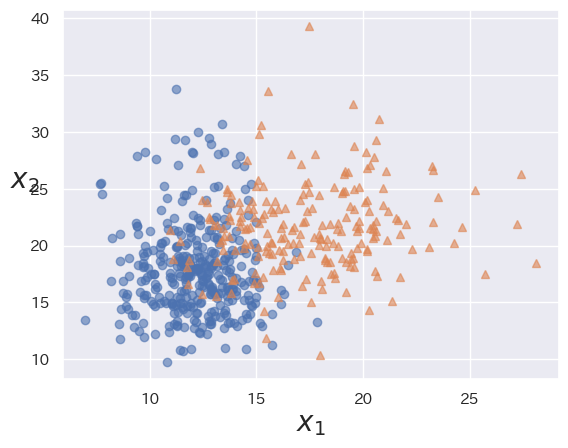

In [63]:
from sklearn.preprocessing import LabelEncoder

X,y = df.loc[:,2:].values, df.loc[:,1].values

le = LabelEncoder()
y = le.fit_transform(y)
import common
common.plot_dataset(X,y)
print("Classes: %s"%le.classes_)

X

In [64]:
'''
6.1.2 パイプラインによる変換器、推定機の結合

1. 標準化
2. 次元圧縮(PCA)

'''
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
import numpy as np
from sklearn.model_selection import train_test_split

results = []
for i in range(100):
  #NOTE: データセットの分割
  #訓練データ80 % + テストデータ 20%
  X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, stratify =y, random_state=1)
  '''
  test_size: テストデータの割合
  stratify: 層化抽出: 引数stratify
    引数stratifyに均等に分割させたいデータ（多くの場合は正解ラベル）を指定すると、
    そのデータの値の比率が一致するように分割される。
    教師あり学習のためにデータを分割する場合、訓練用とテスト用の正解ラベルの比率は
    元のデータの正解ラベルの比率と一致していることが望ましい
    正解比率が等しくなるよう、分割する
  '''
  pipe_lr = make_pipeline(
    StandardScaler(),#標準化
    PCA(n_components=2),#PCA
    LogisticRegression(random_state=1, solver='liblinear')
  )
  pipe_lr.fit(X_train, y_train)
  y_pred = pipe_lr.predict(X_test)
  results.append(np.round(pipe_lr.score(X_test, y_test),3))


print('Test Accueracy: Samples %d, Avg %.3f ± %.3f'%(len(results),np.mean(results),np.std(results))) 
      
      

Test Accueracy: Samples 100, Avg 0.956 ± 0.000


#### 6.2 k分割交差検証を使ったモデル性能評価

モデルにとって未知のデータを使って性能評価を行う
  モデル選択: 未知のデータに対する予測性能向上のために、様々なパラメタ設定(ハイパーパラメータ)のチューニングや比較を行うこと。端的には、チューニングパラメタの最適な値を選択する分類問題に相当。
  モデル選択において、同じテストデータセットを繰り返し使った場合、それは訓練データセットの一部になってしまい、モデルの過学習につながる。


##### ホールド・アウト法
  データを「訓練データセット」、「検証データセット」、「テストデータセット」に分割する

- <u>訓練データセット(Training Set)</u>: 様々のモデルの学習に使う。
- 検証データセット(Validation Set): モデル選択(ハイパーパラメータ評価)のためにモデル性能を評価する
  
- テストデータセット(Test Set): 未知のデータに対する予測性能評価(汎化誤差)



<p><img src="ch06/images/06_02.png" width = "50%"/></p> 


##### k分割交差検証

非復元抽出をも用いて、訓練データセットをk個に分割する。
そのうち、k-1個をモデルの訓練に使い、1個を性能評価に使う。
この手順をk回繰り返すことでkこのモデルを取得し、性能を推定する。

次にここのサブセットに基づいてモデルの平均性能を計算する。
訓練データの再分割に敏感ではない性能評価を取得するため。
k分割交差検証はモデルのチューニングに使う。

<p><img src="ch06/images/06_03.png" width = "50%"/></p> 

In [65]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold

#NOTE: 分割元データ、分割数、乱数生成機の状態を指定し、
# 層化k分割交差検証イテレータを表すStrarifiedKFoldクラスのインスタンス化
# 正解データのラベル比率が等しい
skfold = StratifiedKFold(n_splits = 10).split(X_train, y_train)
pipe_lr = make_pipeline(
    StandardScaler(),#標準化
    PCA(n_components=2),#PCA
    LogisticRegression(random_state=1, solver='lbfgs')
  )


results = []
for k, (train, test ) in enumerate(skfold):



  pipe_lr.fit(X_train[train], y_train[train])
  score = pipe_lr.score(X_train[test], y_train[test])

  print('Fold: %2d, Class dist.: %s, Acc: %.3f' % (k+1,
      np.bincount(y_train[train]), score))
    
  results.append(score)


print('Test Accueracy: Samples %d, Avg %.3f ± %.3f'%(len(results),np.mean(results),np.std(results))) 
      


Fold:  1, Class dist.: [256 153], Acc: 0.935
Fold:  2, Class dist.: [256 153], Acc: 0.935
Fold:  3, Class dist.: [256 153], Acc: 0.957
Fold:  4, Class dist.: [256 153], Acc: 0.957
Fold:  5, Class dist.: [256 153], Acc: 0.935
Fold:  6, Class dist.: [257 153], Acc: 0.956
Fold:  7, Class dist.: [257 153], Acc: 0.978
Fold:  8, Class dist.: [257 153], Acc: 0.933
Fold:  9, Class dist.: [257 153], Acc: 0.956
Fold: 10, Class dist.: [257 153], Acc: 0.956
Test Accueracy: Samples 10, Avg 0.950 ± 0.014


In [66]:
# #通常のk分割交差検証イテレータの場合
# # 正解データのラベル比率が等しくない
# results = []
# pipe_lr = make_pipeline(
#     StandardScaler(),#標準化
#     PCA(n_components=2),#PCA
#     LogisticRegression(random_state=1, solver='lbfgs')
#   )
# kfold = KFold(n_splits =100).split(X_train, y_train)
# for k, (train, test ) in enumerate(kfold):


#   pipe_lr.fit(X_train[train], y_train[train])
#   results.append(np.round(pipe_lr.score(X_train[test], y_train[test]),3))


# print('Test Accueracy: Samples %d, Avg %.3f ± %.3f'%(len(results),np.mean(results),np.std(results))) 

scikit-learnによるk分割交差検証の評価

In [67]:
from sklearn.model_selection import cross_val_score
# NOTE: 交差検証のcross_val_score関数でモデルの正解率を算出


scores = cross_val_score(
  estimator = pipe_lr,#suiteiki 
  X = X_train, y = y_train,
  cv = 10,#分割数
  n_jobs = -1# 処理分割: サブセットごとの評価の計算処理を複数CPUに分散
)
print('CV accuracy score: %.3f ± %.3f '%(np.mean(scores),np.std(scores)))

CV accuracy score: 0.950 ± 0.014 


##### 学習曲線と検証曲線によるアルゴリズムの診断

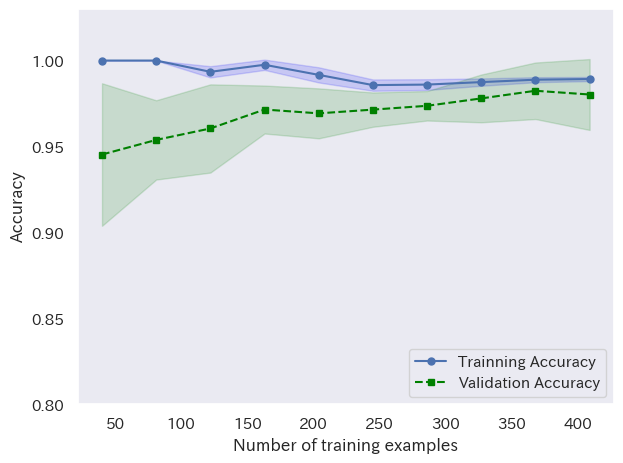

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn.model_selection import learning_curve

pipe_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(
      penalty = 'l2',
      random_state = 1,
      solver = 'lbfgs',
      max_iter = 10000
  ))

train_sizes, train_scores, test_scores = learning_curve(
  estimator = pipe_lr, X = X_train, y = y_train,
  train_sizes = np.linspace(0.1, 1.0, 10),
  cv = 10, n_jobs = 1
)

train_mean = np.mean(train_scores, axis = 1)
train_std = np.std(train_scores, axis = 1)

test_mean = np.mean(test_scores, axis = 1)
test_std = np.std(test_scores, axis = 1)


plt.plot(train_sizes, train_mean, marker = 'o', markersize = 5, label = 'Trainning Accuracy')
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha = 0.15, color = 'blue')

plt.plot(train_sizes, test_mean, color = 'green', linestyle = '--' ,marker = 's', markersize = 5, label = 'Validation Accuracy')
plt.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha = 0.15, color = 'green')

plt.grid()
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.ylim([0.8,1.03])
plt.tight_layout()

plt.show()

#### 検証曲線を使って過学習と学習不足を明らかにする

横軸にモデルのパラメタ、縦軸にスコア(精度)をプロットして、
最適なスコアを算出する
ロジスティック回帰の逆正則化パラメタCを変えながら実行

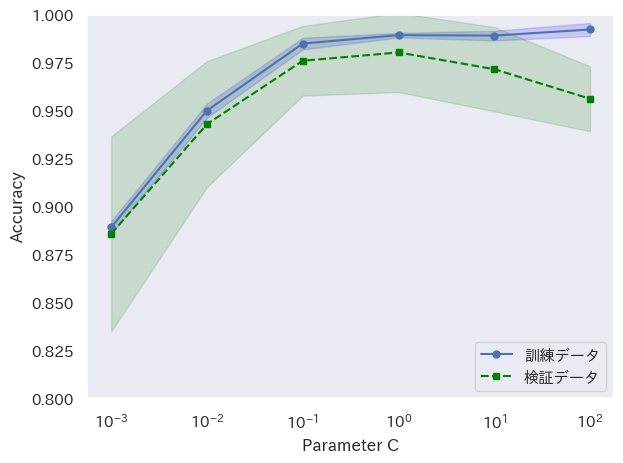

In [78]:
from sklearn.model_selection import validation_curve
param_range = [10**(idx-3) for idx in range(6)]
# param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
# NOTE: validation_curve関数によりモデルのパラメータを変化させ、交差検証による正解率を算出
# clf__C はLogicsitRegression Objectのパラメータ

train_scores, test_scores = validation_curve(
    estimator = pipe_lr, X = X_train, y = y_train,
    param_name = 'logisticregression__C', param_range= param_range, cv = 10 
  )

train_mean = np.mean(train_scores, axis = 1);train_std = np.std(train_scores, axis = 1)
test_mean = np.mean(test_scores, axis = 1);test_std = np.std(test_scores, axis = 1)

plt.plot(param_range, train_mean, marker = 'o', markersize = 5, label = '訓練データ')
plt.fill_between(param_range, train_mean + train_std, train_mean - train_std, alpha = 0.15, color = 'blue')

plt.plot(param_range, test_mean, color = 'green', linestyle = '--' ,marker = 's', markersize = 5, label = '検証データ')
plt.fill_between(param_range, test_mean + test_std, test_mean - test_std, alpha = 0.15, color = 'green')

plt.grid();plt.xscale('log');plt.xlabel('Parameter C');plt.ylabel('Accuracy')
plt.legend(loc='lower right');plt.ylim([0.8,1.0]);plt.tight_layout();plt.show()

# 左側: 正則化強め⇢訓練/検証データいずれも精度低め ⇢ 学習不足
# 右側: 正則化弱め⇢訓練データ精度高 / 検証データ精度低 ⇢ 過学習気味


#### 6.4 グリッドサーチによる機械学習モデルのチューニング

- 訓練データから学習するパラメータ
- (個別に最適化する)学習アルゴリズムのパラメータ

  例: ロジスティック回帰正則化パラメータ、決定木の深さパラメータなど


In [79]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
import json

pipe_svc = make_pipeline(StandardScaler(), SVC(random_state = 1))

param_grid =[
    {'svc__C': param_range, 'svc__kernel': ['linear']},
    {'svc__C': param_range, 'svc__gamma': param_range, 'svc__kernel':['rbf']}
  ]

gs = GridSearchCV(
    estimator = pipe_svc,
    param_grid = param_grid,
    scoring = 'accuracy',
    cv = 10,
    refit = True,
    n_jobs = -1
  )

gs = gs.fit(X_train, y_train)

print("Best Score: \t\t%.3f"%gs.best_score_)
print("Best Parameter: \t%s"%json.dumps(gs.best_params_,indent = 4))

Best Score: 		0.985
Best Parameter: 	{
    "svc__C": 100,
    "svc__gamma": 0.001,
    "svc__kernel": "rbf"
}


##### 6.4.2 入れ子式交差検証によるアルゴリズムの選択

<p><img src="ch06/images/06_07.png" width = "50%"/></p> 

考え方

外側ループ: ｋ分割交差検証⇢ データを訓練サブセットとテストサブセットに分割する。

内側ループ: k分割交差検証: 訓練サブセットに対してk分割交差検証を行ってモデル性能を評価する




In [83]:
gs = GridSearchCV(
  estimator = pipe_svc,
  param_grid = param_grid,
  scoring = 'accuracy', cv = 2
)

scores = cross_val_score(gs, X_train,y_train, scoring = 'accuracy', cv = 5)


print('CV accuracy %.3f +/- %.3f'%(np.mean(scores),np.std(scores)))

CV accuracy 0.974 +/- 0.015


In [82]:
from sklearn.tree import DecisionTreeClassifier

#NOTE: ハイパパラメタ値として決定木の深さパラメタを指定し、
# グリッドサーチを行うGridSrarchCVクラスをインスタンス化

gs = GridSearchCV(
  estimator = DecisionTreeClassifier(random_state = 0),
  param_grid = [{'max_depth': [1,2,3,4,5,6,7,None]}],
  scoring = 'accuracy', cv = 2
)

scores = cross_val_score(gs, X_train,y_train, scoring = 'accuracy', cv = 5)


print('CV accuracy %.3f +/- %.3f'%(np.mean(scores),np.std(scores)))

CV accuracy 0.934 +/- 0.016


In [73]:
scores

array([0.93859649, 0.88986784])

#### 6.5 様々な性能評価指標

正解率以外の性能評価指標を導入する。

適合率(precision)

再現率(recall)

混同行列

・真陽性(true positive)
・真陰性(true negative)
・偽陽性(flase positive)
・偽陰性(false negative)

<p><img src="ch06/images/06_08.png" width = "30%"/></p> 

[[71  1]
 [ 2 40]]


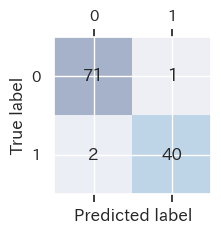

In [84]:
from sklearn.metrics import confusion_matrix

pipe_svc.fit(X_train, y_train)

y_pred = pipe_svc.predict(X_test)

confmat = confusion_matrix(y_true = y_test, y_pred = y_pred)

print(confmat)

fig, ax = plt.subplots(figsize = (2.5, 2.5))

#NOTE: matshow関数で行列からヒートマップを描画
ax.matshow(confmat, cmap = plt.cm.Blues, alpha = 0.3)

for i in range(confmat.shape[0]):
  for j in range(confmat.shape[1]):
    ax.text(x=j, y=i, s= confmat[i,j], va = 'center', ha = 'center')
    
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()


<p><img src="ch06/images/06_08.png" width = "30%"/></p> 

##### 6.5.2 分類モデルの適合率と再現率の最適化


TPR: 全ての Positive のうち、実際に Postitive だったものを正しく Positive と判定できた割合

FPR:  全ての Negative のうち、実際には Negative だったが間違えて Positive と判定した割合


誤分類率(ERR): 全体に占める誤り(陽性を陰性判定、陰性を陽性判定)の割合

$ERR = \frac{FP+FN}{FP+FN+TP+TN}=\frac{誤り}{全体}$

正解率: 全体に占める正解の割合

$ACC = \frac{TP+TN}{FP+FN+TP+TN}=\frac{正解}{全体}= 1- \frac{誤り}{全体} = 1- ERR$

真陽性率(TPR): 全陽性:「陽性」もののうち、「陽性」と判定できた割合

$TPR = \frac{TP}{FN+TP}$

偽陽性率(FPR): 全陰性のうち、「陽性」と判定してしまった割阿智

$FPR = \frac{FP}{FP+FN+TP+TN}$


適合率()PRE: 陽性判定のうち、実際に予定だった物の数

$PRE = \frac{TP}{TP+FP}$

ROC曲線: 横軸に1-Specificity(False Positive Rate)を，縦軸にSensitivity(True Positive Rate)をとり，閾値を変えていったときのそれぞれの値の推移をplotしています．
AUC: ROC 曲線と TPR=0、FPR=1 の直線で囲まれる部分の面積。

<p><img src="https://blog.kikagaku.co.jp/wordpress/wp-content/uploads/2022/01/%E3%82%B9%E3%83%A9%E3%82%A4%E3%83%88%E3%82%9920.png" width = "50%"/></p> 


In [88]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score, f1_score

print('Precision: %.3f'%precision_score(y_true=y_test, y_pred = y_pred))
print('Recall: %.3f'%recall_score(y_true=y_test, y_pred = y_pred))
print('F1: %.3f'%f1_score(y_true = y_test, y_pred = y_pred))


#NOTE: カスタム性能指標出力

from sklearn.metrics import make_scorer, f1_score
c_gamma_range = [0.01, 0.1, 1.0, 10.0]

param_grid = [
  {"svc__C": c_gamma_range, 'svc__kernel': ['linear']},
  {"svc__C": c_gamma_range, 'svc__gamma': c_gamma_range,'svc__kernel': ['rbf']},
]

scorer = make_scorer(f1_score, pos_label=0)

gs = GridSearchCV(estimator=pipe_svc, param_grid = param_grid, scoring = scorer, cv = 10, n_jobs =-1)
gs.fit(X_train, y_train)

print("Best Score: %.3f"%gs.best_score_)

print("Best params: %s"%gs.best_params_)


Precision: 0.976
Recall: 0.952
F1: 0.964
Best Score: 0.986
Best params: {'svc__C': 10.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}


#### ROC曲線

ROC(Receiver Operating Characteristic: 受信者操作特性)曲線
性能に基づいて分類モデルを選択するための便利なツール。



56 56
53 53
56 56


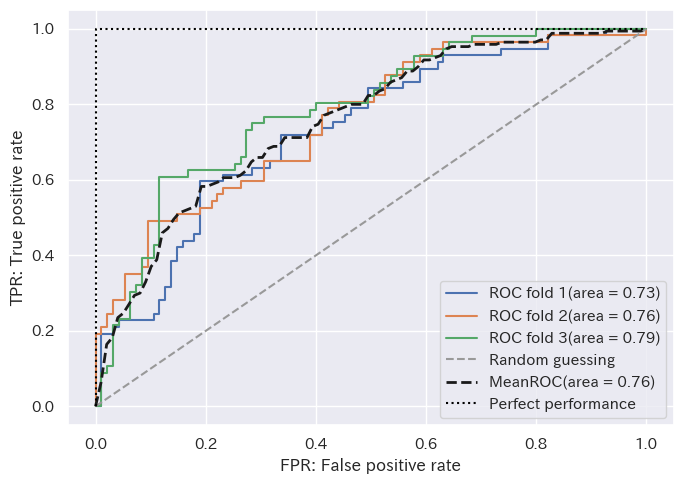

In [113]:
from sklearn.metrics import roc_curve, auc
from numpy import interp

pipe_lr = make_pipeline(
    StandardScaler(),
    PCA(n_components = 2),
    LogisticRegression(penalty='l2', random_state=1, solver='lbfgs', C = 100)
  )

#NOTE: ２つの特徴量を抽出。PCA未使用(ROCを効果を見せるためにあえて精度を落とすため)
X_train2 = X_train[:,[4,14]]

cv = list(StratifiedKFold(n_splits = 3).split(X_train, y_train))

fig = plt.figure(figsize=(7,5))

mean_tpr = 0.0

mean_fpr = np.linspace(0,1,100)
all_tpr = []


for i, (tr, tst) in enumerate(cv):
  #NOTE: fitでモデルに適合後、predict_probaメソッドで確率を予測。
  probas = pipe_lr.fit(X_train2[tr], y_train[tr]).predict_proba(X_train2[tst])

  #NOTE: roc_curveでROC曲線の性能を計算してプロット
  
  fpr, tpr, thresh = roc_curve(y_train[tst], probas[:,1], pos_label=1)
  
  print(len(fpr),len(tpr))
  
  mean_tpr += interp(mean_fpr, fpr, tpr)

  mean_tpr[0] = 0.0

  roc_auc = auc(fpr, tpr)
  plt.plot(fpr, tpr, label = 'ROC fold %d(area = %0.2f)'%(i+1, roc_auc))

#NOTE: 当て推量プロット
plt.plot([0,1],[0,1], linestyle="--", color = (0.6, 0.6, 0.6), label = 'Random guessing')

# FPR, TPR, ROC AUCそれぞれの平均を計算してプロット
mean_tpr /= len(cv)

mean_tpr[-1] = 1.0

mean_auc = auc(mean_fpr, mean_tpr)

plt.plot(mean_fpr, mean_tpr, 'k--', label='MeanROC(area = %0.2f)'%mean_auc, lw = 2)
plt.plot([0, 0, 1],
         [0, 1, 1],
         linestyle=':',
         color='black',
         label='Perfect performance')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('FPR: False positive rate')
plt.ylabel('TPR: True positive rate')
plt.legend(loc="lower right")

plt.tight_layout()
# plt.savefig('ch06/images/06_10.png', dpi=300)
plt.show()


すべての特徴量を利用した場合
<p><img src="ch06/images/06_10.png" width = "69%"/></p> 